## The first phase of the model - Regression Panel

In [14]:
# Packages
install.packages(c("plm", "lmtest", "readxl", "car", "nortest", "tseries", "psych", "corrplot"))

Warning message:
"packages 'plm', 'lmtest', 'readxl', 'car', 'nortest', 'tseries', 'psych', 'corrplot' are in use and will not be installed"


In [ ]:
# Loading the libraries required for panel data analysis,
library(plm)
library(lmtest)
library(readxl)
library(car)
library(nortest)
library(tseries)
library(psych)
library(corrplot)

In [16]:
# Reading the data
df <- read_excel("panel_data.xlsx")
df <- data.frame(df)

In [17]:
# Rename columns
names(df) <- c(
  "County",
  "Years",
  "Dependency_index",
  "Enterprises_per_capita",
  "FDI_per_capita",
  "Occupancy_rate",
  "Real_salary",
  "Immigrants"
)


In [18]:
# Check structure
str(df)
summary(df)

'data.frame':	504 obs. of  8 variables:
 $ County                : chr  "Alba" "Alba" "Alba" "Alba" ...
 $ Years                 : num  2013 2014 2015 2016 2017 ...
 $ Dependency_index      : num  48.3 48.5 49.2 50 51.3 ...
 $ Enterprises_per_capita: num  21.6 22.4 23 23.8 24.7 ...
 $ FDI_per_capita        : num  2.61 3.53 2.87 3.31 2.5 ...
 $ Occupancy_rate        : num  71.3 70.2 70.7 71.9 74.1 ...
 $ Real_salary           : num  2061 2208 2462 2782 3196 ...
 $ Immigrants            : num  2714 2403 2346 2428 3134 ...


    County              Years      Dependency_index Enterprises_per_capita
 Length:504         Min.   :2013   Min.   :37.11    Min.   : 9.286        
 Class :character   1st Qu.:2016   1st Qu.:49.08    1st Qu.:19.618        
 Mode  :character   Median :2018   Median :53.30    Median :23.750        
                    Mean   :2018   Mean   :52.76    Mean   :26.526        
                    3rd Qu.:2021   3rd Qu.:56.65    3rd Qu.:30.251        
                    Max.   :2024   Max.   :68.57    Max.   :79.500        
 FDI_per_capita     Occupancy_rate    Real_salary     Immigrants   
 Min.   :-0.00645   Min.   : 37.39   Min.   :1760   Min.   : 1399  
 1st Qu.: 0.54253   1st Qu.: 54.78   1st Qu.:2610   1st Qu.: 2745  
 Median : 1.22676   Median : 59.87   Median :3518   Median : 3920  
 Mean   : 2.40736   Mean   : 60.68   Mean   :3382   Mean   : 4675  
 3rd Qu.: 2.52145   3rd Qu.: 65.32   3rd Qu.:3913   3rd Qu.: 5547  
 Max.   :40.16996   Max.   :116.47   Max.   :6730   Max.   :27187  

In [19]:
# Convert variables
df$County <- as.factor(df$County)
df$Years <- as.numeric(df$Years)

In [20]:
# Used variables
var <- df[, c(
  "Dependency_index",
  "Enterprises_per_capita",
  "FDI_per_capita",
  "Occupancy_rate",
  "Real_salary",
  "Immigrants"
)]

In [21]:
# Correlation matrix
cor_matrix <- cor(var, use = "complete.obs", method = "pearson")
round(cor_matrix, 3)

,Dependency_index,Enterprises_per_capita,FDI_per_capita,Occupancy_rate,Real_salary,Immigrants
Dependency_index,1.000,-0.287,-0.269,-0.295,0.180,0.003
Enterprises_per_capita,-0.287,1.000,0.798,0.645,0.707,0.675
FDI_per_capita,-0.269,0.798,1.000,0.636,0.546,0.697
Occupancy_rate,-0.295,0.645,0.636,1.000,0.290,0.394
Real_salary,0.180,0.707,0.546,0.290,1.000,0.671
Immigrants,0.003,0.675,0.697,0.394,0.671,1.000


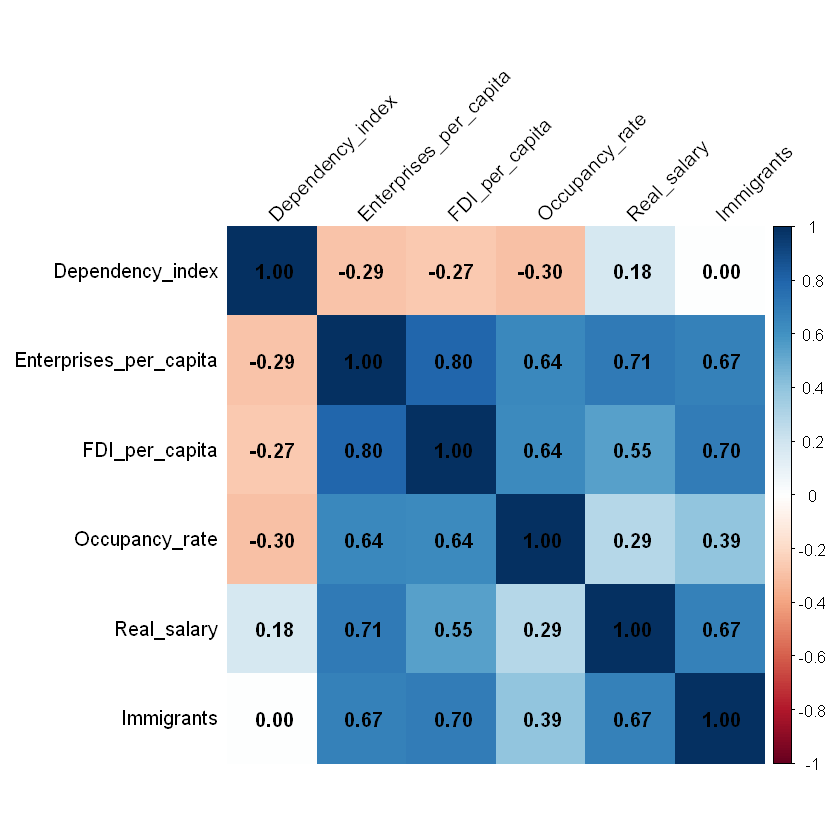

In [22]:
# Heat-map correlation
corrplot(
  cor_matrix,
  method = "color",
  type = "full",
  addCoef.col = "black",
  tl.col = "black",
  tl.srt = 45,
  diag = TRUE
)

### Correlation Matrix Interpretation

The correlation matrix highlights the relationships between the variables included in the analysis.

The strongest positive correlation with temporary immigration is observed for FDI per capita (0.70), suggesting that counties with higher foreign direct investments tend to attract more temporary immigrants.

A strong positive relationship is also identified between real salary and temporary immigrants (0.67), as well as between enterprises per capita and immigrants (0.67). This may indicate that economically developed counties attract a larger number of temporary immigrants.

The occupancy rate presents a moderate positive correlation with immigration (0.39), indicating a weaker but still positive association.

The dependency index shows almost no correlation with temporary immigrants (0.00), suggesting that demographic dependency may not have a direct linear relationship with immigration in the analyzed period.

Regarding the independent variables, several relatively strong correlations can be observed, especially between enterprises per capita and FDI per capita (0.80). However, the correlations are not excessively high, which may indicate that multicollinearity is not severe.

In [23]:
# Panel data structure
pdata <- pdata.frame(df, index = c("County", "Years"))

In [24]:
# Fixed effects model
model_fe <- plm(
  Immigrants ~ Dependency_index +
    Enterprises_per_capita +
    FDI_per_capita +
    Occupancy_rate +
    Real_salary,
  data = pdata,
  model = "within"
)

### Fixed Effects (FE) Model

This panel model estimates the influence of explanatory variables on the number of temporary immigrants between counties and over time.

The fixed effects model ("within") controls for the characteristics specific to each county that do not change over time (e.g. geographical position, local culture, historical infrastructure etc.).

Basically, the model analyzes:

> "How does the number of immigrants change in a county when the explanatory variables change in that county over time?"

Thus, the effects of factors constant over time are eliminated, reducing the risk of bias caused by unobserved heterogeneity.

- `model = "within"` → Fixed Effects estimator

In [25]:
# Random effects model
model_re <- plm(
  Immigrants ~ Dependency_index +
    Enterprises_per_capita +
    FDI_per_capita +
    Occupancy_rate +
    Real_salary,
  data = pdata,
  model = "random"
)

### Random Effects (RE) Model

This panel model estimates the influence of explanatory variables on the number of temporary immigrants between counties and over time.

The random effects model assumes that the specific differences of each county (individual effects) are random and are not correlated with the explanatory variables included in the model.

Unlike the fixed effects model, the Random Effects (RE) model uses both:
- variation over time within counties;
- variation between counties.

Therefore, the model may be more statistically efficient. However, its validity depends on the assumption that unobserved individual effects are not correlated with the explanatory variables.

The choice between the Fixed Effects (FE) and Random Effects (RE) models is usually made using the Hausman test.

- `model = "random"` → Random Effects estimator

In [ ]:
# Results of the model with fixed effects (FE)
summary(model_fe)

Oneway (individual) effect Within Model

Call:
plm(formula = Immigrants ~ Dependency_index + Enterprises_per_capita + 
    FDI_per_capita + Occupancy_rate + Real_salary, data = pdata, 
    model = "within")

Balanced Panel: n = 42, T = 12, N = 504

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-4502.163  -606.339    43.061   520.139  4307.627 

Coefficients:
                        Estimate Std. Error t-value  Pr(>|t|)    
Dependency_index       249.50352   34.77011  7.1758 2.923e-12 ***
Enterprises_per_capita 163.25282   30.18468  5.4085 1.027e-07 ***
FDI_per_capita         389.89786   47.67222  8.1787 2.862e-15 ***
Occupancy_rate         -90.81415   15.29546 -5.9373 5.738e-09 ***
Real_salary             -0.59474    0.15155 -3.9244 0.0001003 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    1505100000
Residual Sum of Squares: 463420000
R-Squared:      0.6921
Adj. R-Squared: 0.6611
F-statistic: 205.447 on 5 and 457 DF, p-va

### Fixed Effects Model Interpretation

The Fixed Effects model analyzes how changes within each county over time influence the number of temporary immigrants.

The model is statistically significant overall (p-value < 0.001), indicating that the explanatory variables jointly have a significant effect on temporary immigration.

The R-squared value (0.6921) shows that approximately 69.2% of the variation in temporary immigrants is explained by the variables included in the model.

FDI per capita has a positive and statistically significant effect on temporary immigration. An increase of one unit in FDI per capita is associated with an average increase of approximately 390 temporary immigrants, holding the other variables constant.

Enterprises per capita also has a positive and significant influence. Counties with a higher number of enterprises per capita tend to attract more temporary immigrants.

The dependency index has a positive and statistically significant coefficient, suggesting that increases in demographic dependency are associated with increases in temporary immigration.

Occupancy rate has a negative and statistically significant effect, indicating that increases in the occupancy rate are associated with lower levels of temporary immigration.

Real salary also presents a negative and statistically significant coefficient, suggesting that increases in salaries are associated with a slight decrease in temporary immigration, after controlling for the other variables.

Overall, the results suggest that economic factors such as foreign investments and business activity play an important role in attracting temporary immigrants across counties.

In [ ]:
# Results of the model with random effects (RE)
summary(model_re)

Oneway (individual) effect Random Effect Model 
   (Swamy-Arora's transformation)

Call:
plm(formula = Immigrants ~ Dependency_index + Enterprises_per_capita + 
    FDI_per_capita + Occupancy_rate + Real_salary, data = pdata, 
    model = "random")

Balanced Panel: n = 42, T = 12, N = 504

Effects:
                  var std.dev share
idiosyncratic 1014055    1007 0.321
individual    2143851    1464 0.679
theta: 0.8053

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-5176.322  -553.050   -15.032   491.042  4713.362 

Coefficients:
                          Estimate  Std. Error z-value  Pr(>|z|)    
(Intercept)            -5372.11049  1260.94629 -4.2604 2.041e-05 ***
Dependency_index         208.76769    24.44794  8.5393 < 2.2e-16 ***
Enterprises_per_capita   163.62272    21.80388  7.5043 6.176e-14 ***
FDI_per_capita           377.26644    42.90665  8.7927 < 2.2e-16 ***
Occupancy_rate           -79.18235    13.07993 -6.0537 1.415e-09 ***
Real_salary               -0.41709 

In [30]:
# Hausman test: FE vs RE
hausman_test <- phtest(model_fe, model_re)
hausman_test


	Hausman Test

data:  Immigrants ~ Dependency_index + Enterprises_per_capita + FDI_per_capita +  ...
chisq = 41.403, df = 5, p-value = 7.779e-08
alternative hypothesis: one model is inconsistent


### Hausman Test Interpretation

The Hausman test was used to determine whether the Fixed Effects (FE) model or the Random Effects (RE) model is more appropriate for the analysis.

The null hypothesis of the test states that the Random Effects model is consistent and appropriate, meaning that the individual effects are not correlated with the explanatory variables.

Since the p-value is very small (p-value < 0.05), the null hypothesis is rejected.

Therefore, the Fixed Effects model is considered more appropriate for the analysis, suggesting that the unobserved county-specific effects are correlated with the explanatory variables included in the model.

In [31]:
# VIF check using pooled OLS
vif_model <- lm(
  Immigrants ~ Dependency_index +
    Enterprises_per_capita +
    FDI_per_capita +
    Occupancy_rate +
    Real_salary,
  data = df
)

vif(vif_model)

Dependency_index Enterprises_per_capita         FDI_per_capita 
              1.607653               5.657279               2.975060 
        Occupancy_rate            Real_salary 
              2.035345               3.180896

### Multicollinearity Test (VIF) Interpretation

The Variance Inflation Factor (VIF) test was used to evaluate the presence of multicollinearity among the explanatory variables.

The VIF values for all variables are below the commonly accepted threshold of 10, indicating that severe multicollinearity is not present in the model.

The highest VIF value is observed for enterprises per capita (5.66), suggesting a moderate correlation with the other explanatory variables, but still within acceptable limits.

Overall, the results indicate that the independent variables can be included simultaneously in the regression model without major multicollinearity concerns.

In [32]:
# Heteroscedasticity test – Breusch-Pagan
bptest_fe <- bptest(model_re, studentize = TRUE)
print(bptest_fe)



	studentized Breusch-Pagan test

data:  model_re
BP = 191.79, df = 5, p-value < 2.2e-16



### Heteroskedasticity Test Interpretation

The studentized Breusch-Pagan test was used to verify the presence of heteroskedasticity in the regression model.

The null hypothesis of the test states that the residuals have constant variance (homoskedasticity).

Since the p-value is extremely small (p-value < 0.05), the null hypothesis is rejected, indicating the presence of heteroskedasticity.

This means that the variance of the residuals is not constant across observations, which may affect the reliability of the standard errors and statistical tests.

Therefore, the use of robust standard errors is recommended to obtain more reliable coefficient estimates and significance tests.

In [33]:
# Autocorrelation test – Wooldridge
pbgtest(model_re)


	Breusch-Godfrey/Wooldridge test for serial correlation in panel models

data:  Immigrants ~ Dependency_index + Enterprises_per_capita + FDI_per_capita +  ...
chisq = 236.5, df = 12, p-value < 2.2e-16
alternative hypothesis: serial correlation in idiosyncratic errors


### Autocorrelation Test Interpretation

The Wooldridge / Breusch-Godfrey test for autocorrelation was used to verify whether the residuals of the panel model are correlated over time.

The null hypothesis of the test states that there is no serial autocorrelation in the residuals.

If the p-value is lower than 0.05, the null hypothesis is rejected, indicating the presence of autocorrelation.

In the presence of autocorrelation, the standard errors of the coefficients may become biased, which can affect the statistical significance tests. Therefore, the use of robust standard errors is recommended.

In [34]:
# Test cross-sectional dependence – CD test
pcdtest(model_re, test = "cd")


	Pesaran CD test for cross-sectional dependence in panels

data:  Immigrants ~ Dependency_index + Enterprises_per_capita + FDI_per_capita +     Occupancy_rate + Real_salary
z = 69.998, p-value < 2.2e-16
alternative hypothesis: cross-sectional dependence


### Cross-Sectional Dependence Test Interpretation

The Pesaran CD test was used to examine the presence of cross-sectional dependence in the panel data model.

The null hypothesis of the test states that the cross-sectional units (counties) are independent from each other.

Since the p-value is extremely small (p-value < 0.05), the null hypothesis is rejected, indicating the presence of cross-sectional dependence.

This suggests that shocks or changes affecting one county may also influence other counties, meaning that the observations are not fully independent across cross-sectional units.

The presence of cross-sectional dependence may affect the efficiency of standard errors and statistical inference. Therefore, robust estimation methods are recommended.

In [35]:
# Residual normality test – Anderson Darling
residuals_re <- residuals(model_re)
ad.test(residuals_re)


	Anderson-Darling normality test

data:  residuals_re
A = 4.1808, p-value = 2.1e-10


### Normality Test Interpretation for the Random Effects Model

The Anderson-Darling test was used to examine whether the residuals of the Random Effects model follow a normal distribution.

The null hypothesis states that the residuals are normally distributed.

Since the p-value is very small (p-value < 0.05), the null hypothesis is rejected, indicating that the residuals do not follow a normal distribution.

However, in panel data models with a relatively large number of observations, violations of the normality assumption are relatively common and usually do not invalidate the regression results.

To improve the reliability of statistical inference, the use of robust standard errors is recommended.

## Optimization of the model / Final model

In [36]:
# Log transformations
df$log_Immigrants <- log(df$Immigrants)
df$log_Enterprises_per_capita <- log(df$Enterprises_per_capita)
df$log_Real_salary <- log(df$Real_salary)

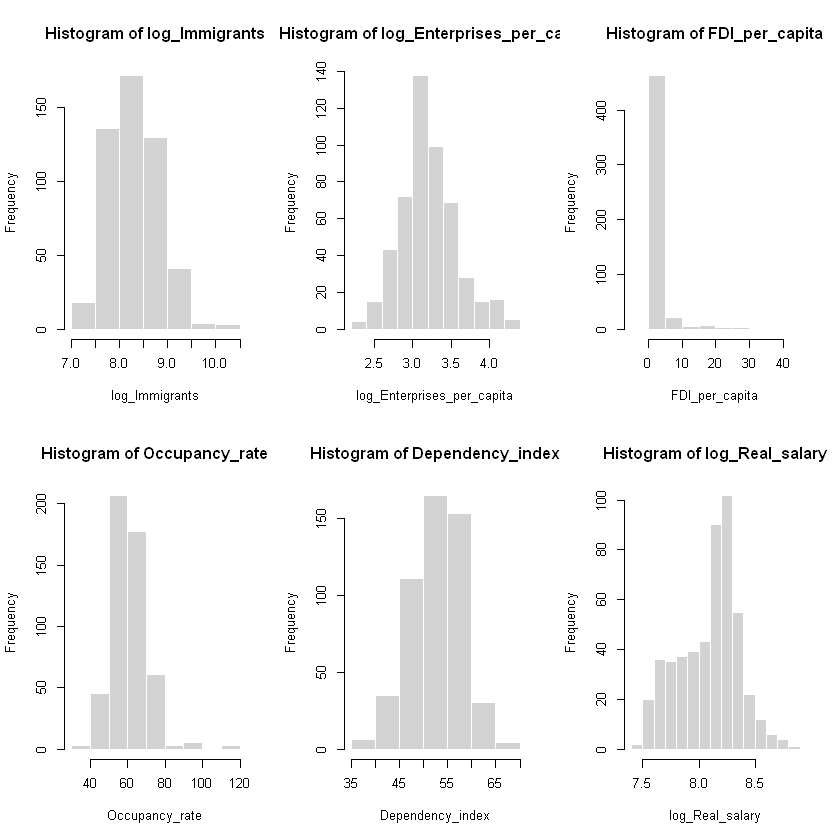

In [42]:
# Histograms for transformed and original variables
hist_vars <- df[, c(
  "log_Immigrants",
  "log_Enterprises_per_capita",
  "FDI_per_capita",
  "Occupancy_rate",
  "Dependency_index",
  "log_Real_salary"
)]

par(mfrow = c(2, 3))

for (v in names(hist_vars)) {
  hist(
    hist_vars[[v]],
    main = paste("Histogram of", v),
    xlab = v,
    col = "lightgray",
    border = "white"
  )
}

par(mfrow = c(1, 1))

In [43]:
# Panel data structure after log transformations
pdata <- pdata.frame(df, index = c("County", "Years"))

In [ ]:
# Fixed effects model with log transformations
model_fe_log <- plm(
  log_Immigrants ~ Dependency_index +
    log_Enterprises_per_capita +
    FDI_per_capita +
    Occupancy_rate +
    log_Real_salary,
  data = pdata,
  model = "within"
)
summary(model_fe_log)

Oneway (individual) effect Within Model

Call:
plm(formula = log_Immigrants ~ Dependency_index + log_Enterprises_per_capita + 
    FDI_per_capita + Occupancy_rate + log_Real_salary, data = pdata, 
    model = "within")

Balanced Panel: n = 42, T = 12, N = 504

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-0.421673 -0.112618  0.024806  0.134539  0.326498 

Coefficients:
                             Estimate Std. Error t-value  Pr(>|t|)    
Dependency_index            0.0327609  0.0054108  6.0547 2.937e-09 ***
log_Enterprises_per_capita  1.2963648  0.1526898  8.4902 2.913e-16 ***
FDI_per_capita              0.0303641  0.0067335  4.5094 8.273e-06 ***
Occupancy_rate             -0.0211604  0.0028567 -7.4072 6.274e-13 ***
log_Real_salary            -0.3084238  0.0816006 -3.7797 0.0001778 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    47.516
Residual Sum of Squares: 12.221
R-Squared:      0.7428
Adj. R-Squared: 0.71691
F-stat

### Log-Log Fixed Effects Model Interpretation

The Fixed Effects model with logarithmic transformations analyzes how changes within each county over time influence temporary immigration.

The model is statistically significant overall (p-value < 0.001), indicating that the explanatory variables jointly have a significant effect on temporary immigration.

The R-squared value (0.7428) shows that approximately 74.3% of the variation in temporary immigrants is explained by the variables included in the model.

The coefficient of log enterprises per capita is positive and statistically significant. Since both variables are expressed in logarithms, the coefficient can be interpreted as an elasticity. A 1% increase in enterprises per capita is associated with an average increase of approximately 1.30% in temporary immigrants, holding the other variables constant.

FDI per capita also has a positive and statistically significant effect, suggesting that increases in foreign direct investments are associated with higher levels of temporary immigration.

The dependency index has a positive and statistically significant coefficient, indicating that increases in demographic dependency are associated with increases in temporary immigration.

Occupancy rate has a negative and statistically significant effect, meaning that higher occupancy rates are associated with lower levels of temporary immigration.

The coefficient of log real salary is negative and statistically significant. A 1% increase in real salary is associated with an average decrease of approximately 0.31% in temporary immigrants, ceteris paribus.

Overall, the results suggest that economic development and business activity positively influence temporary immigration, while higher occupancy rates and real salaries are associated with lower immigration levels.

In [ ]:
# Random effects model with log transformations
model_re_log <- plm(
  log_Immigrants ~ Dependency_index +
    log_Enterprises_per_capita +
    FDI_per_capita +
    Occupancy_rate +
    log_Real_salary,
  data = pdata,
  model = "random"
)
summary(model_re_log)

Oneway (individual) effect Random Effect Model 
   (Swamy-Arora's transformation)

Call:
plm(formula = log_Immigrants ~ Dependency_index + log_Enterprises_per_capita + 
    FDI_per_capita + Occupancy_rate + log_Real_salary, data = pdata, 
    model = "random")

Balanced Panel: n = 42, T = 12, N = 504

Effects:
                  var std.dev share
idiosyncratic 0.02674 0.16353 0.212
individual    0.09916 0.31490 0.788
theta: 0.8517

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.47196 -0.10993  0.02142  0.13415  0.35063 

Coefficients:
                             Estimate Std. Error z-value  Pr(>|z|)    
(Intercept)                 5.9200480  0.3808222 15.5454 < 2.2e-16 ***
Dependency_index            0.0304097  0.0040588  7.4922 6.771e-14 ***
log_Enterprises_per_capita  1.2228281  0.1067884 11.4509 < 2.2e-16 ***
FDI_per_capita              0.0329773  0.0063269  5.2123 1.865e-07 ***
Occupancy_rate             -0.0211405  0.0023033 -9.1782 < 2.2e-16 ***
log_Real_salary      

In [47]:
# Hausman test for final log model
hausman_test_log <- phtest(model_fe_log, model_re_log)
hausman_test_log


	Hausman Test

data:  log_Immigrants ~ Dependency_index + log_Enterprises_per_capita +  ...
chisq = 38.967, df = 5, p-value = 2.412e-07
alternative hypothesis: one model is inconsistent


### Hausman Test Interpretation for the Logarithmic Model

The Hausman test was used to determine whether the Fixed Effects (FE) model or the Random Effects (RE) model is more appropriate for the logarithmic specification of the panel model.

The null hypothesis states that the Random Effects estimator is consistent and efficient, meaning that the unobserved individual effects are not correlated with the explanatory variables.

If the p-value is lower than 0.05, the null hypothesis is rejected, and the Fixed Effects model is preferred.

Therefore, based on the Hausman test results, the Fixed Effects model is considered more appropriate for the analysis of the logarithmic model.

### Residual vs fitted plot

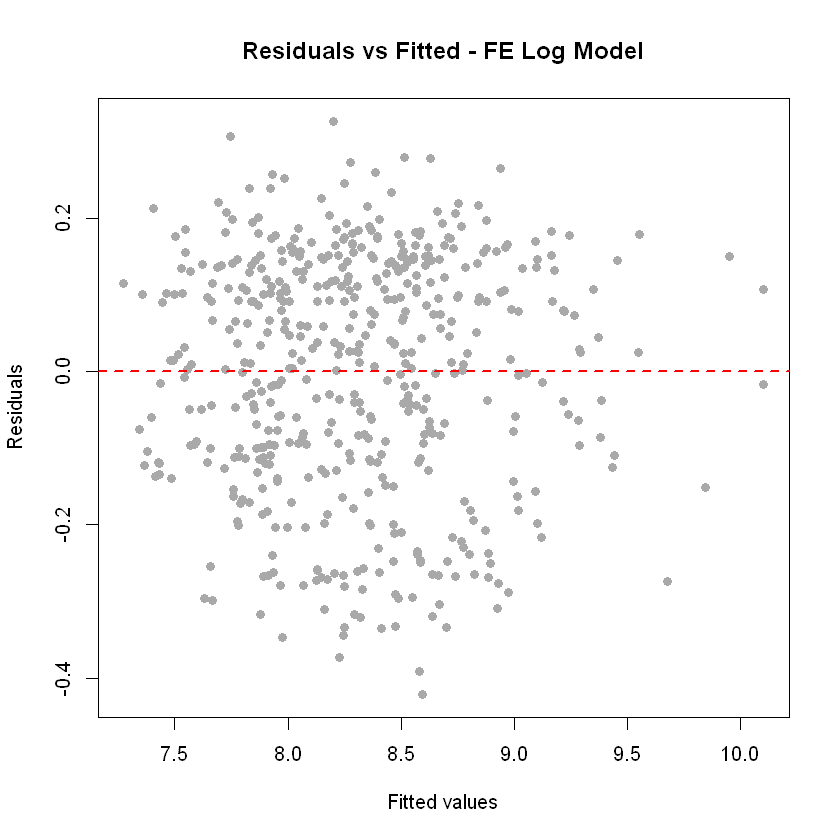

In [49]:
# Actual values
y_actual <- as.numeric(pdata$log_Immigrants)

# Residuals from FE log model
residuals_fe_log <- as.numeric(residuals(model_fe_log))

# Reconstructed fitted values on the original log scale
fitted_fe_log <- y_actual - residuals_fe_log

# Residuals vs fitted plot
plot(
  x = fitted_fe_log,
  y = residuals_fe_log,
  xlab = "Fitted values",
  ylab = "Residuals",
  main = "Residuals vs Fitted - FE Log Model",
  pch = 19,
  col = "darkgray"
)

abline(h = 0, col = "red", lwd = 2, lty = 2)


### Residuals vs Fitted Plot Interpretation

The Residuals vs Fitted plot was used to evaluate the assumptions of the Fixed Effects logarithmic model.

The residuals appear to be relatively randomly distributed around the zero line, without a strong systematic pattern. This suggests that the linear specification of the model is generally appropriate.

The dispersion of the residuals is relatively stable across the fitted values, although a slight variation in spread can still be observed. However, no severe heteroskedasticity pattern is evident in the plot.

Most residuals are concentrated around zero, indicating that the model provides a relatively good fit for the observed data.

Overall, the graphical analysis suggests that the logarithmic Fixed Effects model satisfies the main regression assumptions reasonably well.

In [50]:
# VIF check for final model using pooled OLS
vif_model_log <- lm(
  log_Immigrants ~ Dependency_index +
    log_Enterprises_per_capita +
    FDI_per_capita +
    Occupancy_rate +
    log_Real_salary,
  data = df
)

vif(vif_model_log)

Dependency_index log_Enterprises_per_capita 
                  1.582476                   3.837191 
            FDI_per_capita             Occupancy_rate 
                  2.261188                   2.129272 
           log_Real_salary 
                  2.852321

### Multicollinearity Test Interpretation for the Logarithmic Model

The Variance Inflation Factor (VIF) test was used to assess the presence of multicollinearity among the explanatory variables in the logarithmic model.

All VIF values are below the commonly accepted threshold of 10, indicating that severe multicollinearity is not present.

The highest VIF value is observed for log enterprises per capita (3.84), suggesting a moderate correlation with the other explanatory variables, but still within acceptable limits.

Overall, the results indicate that the explanatory variables can be included simultaneously in the logarithmic regression model without major multicollinearity concerns.

In [51]:
# Breusch-Pagan test
bptest(model_fe_log, studentize = TRUE)


	studentized Breusch-Pagan test

data:  model_fe_log
BP = 73.774, df = 5, p-value = 1.676e-14


### Multicollinearity Test Interpretation for the Logarithmic Model

The Variance Inflation Factor (VIF) test was used to assess the presence of multicollinearity among the explanatory variables in the logarithmic model.

All VIF values are below the commonly accepted threshold of 10, indicating that severe multicollinearity is not present.

The highest VIF value is observed for log enterprises per capita (3.84), suggesting a moderate correlation with the other explanatory variables, but still within acceptable limits.

Overall, the results indicate that the explanatory variables can be included simultaneously in the logarithmic regression model without major multicollinearity concerns.

In [52]:
# Autocorrelation test
pbgtest(model_fe_log)


	Breusch-Godfrey/Wooldridge test for serial correlation in panel models

data:  log_Immigrants ~ Dependency_index + log_Enterprises_per_capita +  ...
chisq = 419.55, df = 12, p-value < 2.2e-16
alternative hypothesis: serial correlation in idiosyncratic errors


### Autocorrelation Test Interpretation for the Logarithmic Model

The Breusch-Godfrey/Wooldridge test was used to examine the presence of serial autocorrelation in the logarithmic panel model.

The null hypothesis states that there is no serial correlation in the idiosyncratic errors.

Since the p-value is extremely small (p-value < 0.05), the null hypothesis is rejected, indicating the presence of serial correlation in the residuals.

This means that the residuals are correlated over time, which may affect the reliability of the standard errors and statistical inference.

Therefore, the use of robust standard errors is recommended in order to obtain more reliable coefficient estimates and significance tests.

In [53]:
# Cross-sectional dependence test
pcdtest(model_fe_log, test = "cd")


	Pesaran CD test for cross-sectional dependence in panels

data:  log_Immigrants ~ Dependency_index + log_Enterprises_per_capita +     FDI_per_capita + Occupancy_rate + log_Real_salary
z = 90.594, p-value < 2.2e-16
alternative hypothesis: cross-sectional dependence


### Cross-Sectional Dependence Test Interpretation for the Logarithmic Model

The Pesaran CD test was used to examine the presence of cross-sectional dependence in the logarithmic panel model.

The null hypothesis states that the cross-sectional units (counties) are independent from each other.

Since the p-value is extremely small (p-value < 0.05), the null hypothesis is rejected, indicating the presence of cross-sectional dependence.

This suggests that economic or social shocks affecting one county may also influence other counties, meaning that the cross-sectional units are not fully independent.

The presence of cross-sectional dependence may affect the efficiency of standard errors and statistical inference. Therefore, the use of robust estimation methods is recommended.

In [54]:
# Anderson-Darling normality test
ad.test(residuals(model_fe_log))


	Anderson-Darling normality test

data:  residuals(model_fe_log)
A = 7.4365, p-value < 2.2e-16


### Normality Test Interpretation for the Residuals

The Anderson-Darling test was used to examine whether the residuals of the logarithmic Fixed Effects model follow a normal distribution.

The null hypothesis states that the residuals are normally distributed.

Since the p-value is extremely small (p-value < 0.05), the null hypothesis is rejected, indicating that the residuals do not follow a normal distribution.

However, in panel data models with a relatively large number of observations, deviations from normality are relatively common and do not necessarily invalidate the model estimates.

To reduce the impact of non-normal residuals and other potential violations of classical assumptions, the use of robust standard errors is recommended.

In [55]:
# Robust standard errors for final FE model
coeftest(
  model_fe_log,
  vcov = vcovHC(
    model_fe_log,
    method = "arellano",
    type = "HC1",
    cluster = "group"
  )
)


t test of coefficients:

                             Estimate Std. Error t value  Pr(>|t|)    
Dependency_index            0.0327609  0.0068973  4.7498 2.730e-06 ***
log_Enterprises_per_capita  1.2963648  0.1553716  8.3436 8.601e-16 ***
FDI_per_capita              0.0303641  0.0063874  4.7538 2.679e-06 ***
Occupancy_rate             -0.0211604  0.0021962 -9.6351 < 2.2e-16 ***
log_Real_salary            -0.3084238  0.0488424 -6.3147 6.421e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### Robust Standard Errors Interpretation

Robust standard errors (Arellano HC1, clustered by group) were used to correct for heteroskedasticity, serial correlation, and cross-sectional dependence identified in the diagnostic tests.

After applying robust standard errors, all explanatory variables remain statistically significant, indicating that the results of the logarithmic Fixed Effects model are robust.

The positive and significant coefficients for the dependency index, enterprises per capita, and FDI per capita suggest that these variables contribute positively to temporary immigration.

At the same time, occupancy rate and real salary maintain negative and statistically significant effects on temporary immigration.

Overall, the robust estimation confirms the validity and stability of the main results obtained from the Fixed Effects logarithmic model.